In [1]:
# enables automatic library refreshes when importing changes to a library
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import socket
import importlib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# loads raw data into a dataframe to be processed
from src.config import raw_data_dir

data_path = raw_data_dir / "sample_data.npy"
sim = np.load(data_path, allow_pickle=True)

df = pd.DataFrame(sim)

In [6]:
# runs RDP algorithm on raw data and saves it in data/processed

from src.config import profile_features, split_feature, num_profile_points, processed_data_path
from src.preprocessing import rdp_preprocess, fit_preprocess_scalers

processed_df = rdp_preprocess(df, num_profile_points)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
np.save(processed_data_path, processed_df)

In [ ]:
# used to visualize which points were selected by rdp algorithm
from src.utils import varify_rdp

varify_rdp(df, processed_df)

In [7]:
# Reconstruct DataFrame from the RDP NumPy array output
column_headers = profile_features + [split_feature]
processed_dataframe = pd.DataFrame(processed_df, columns=column_headers)

# Normalize data
df_scaled, scalers = fit_preprocess_scalers(
    processed_dataframe,
    normalize=True,
    standardize=False,
)

arr = df_scaled.to_numpy()

In [8]:
from src.train import train_model
import src.config

metrics = train_model(arr)


----------------------------------------------------------------------
Ran 0 tests in 0.000s

NO TESTS RAN


Training on device: cuda
Model: VAE(
  (encoder): Sequential(
    (0): Linear(in_features=120, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=128, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): Leaky

(<Figure size 1500x500 with 2 Axes>,
 (<Axes: title={'center': 'Reconstruction Loss (MSE)'}, xlabel='Epoch', ylabel='MSE'>,
  <Axes: title={'center': 'Latent Divergence (KLD)'}, xlabel='Epoch', ylabel='KLD'>))

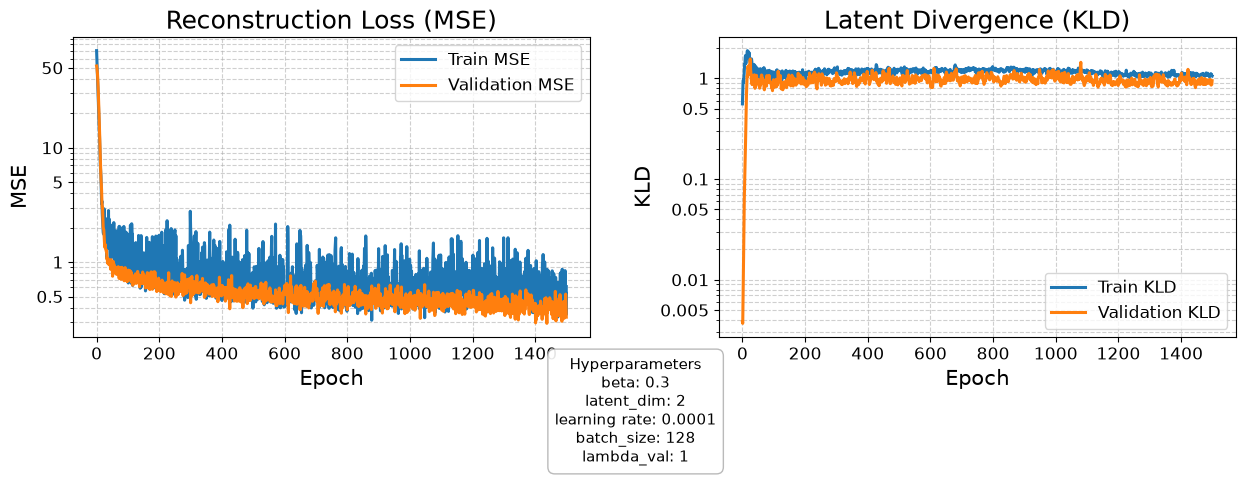

In [9]:
from src.utils import plot_loss_curve

plot_loss_curve(metrics)

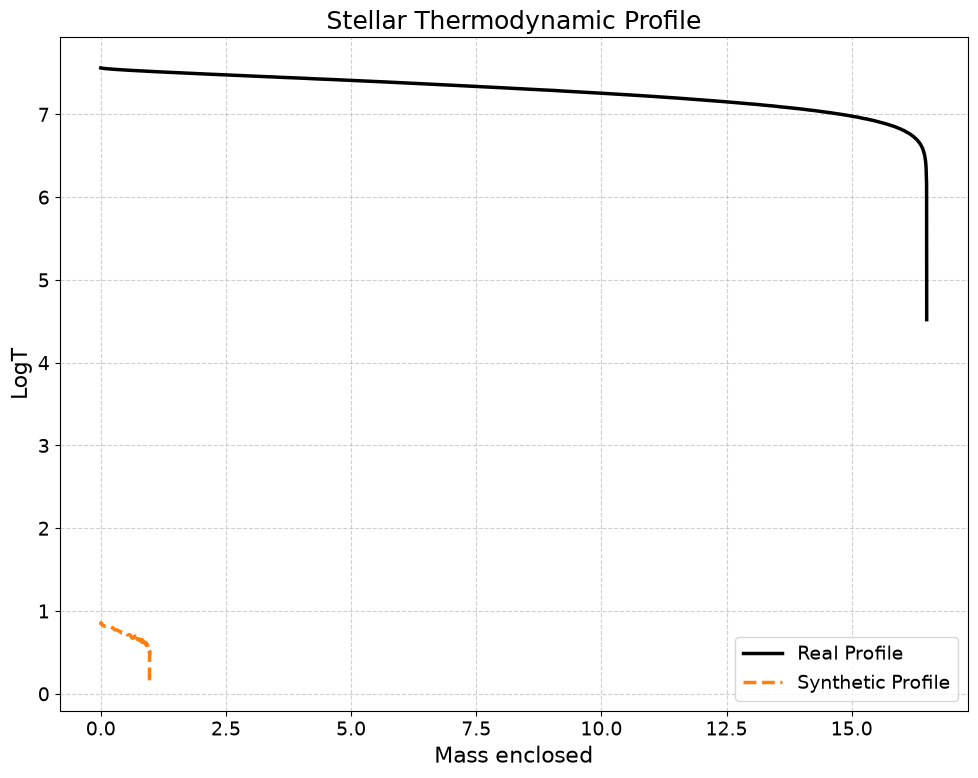

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from src.dataset import get_dataloaders
from src.config import profile_features, num_profile_points, model_save_dir
from src.utils import generate_stellar_profiles

# Replace with your verified model filename
model_path = model_save_dir / "variational_autoencoder.pth" 
synthetic_profiles = generate_stellar_profiles(model_path, num_samples=1)
synthetic_profile = synthetic_profiles[0] 

_, val_loader, _ = get_dataloaders(condition_cols=[2])
real_batch, _ = next(iter(val_loader))
real_profile = real_batch[0].numpy()

fig, ax = plt.subplots(figsize=(10, 8))

# Map Feature 0 (Mass) to X-axis and Feature 1 (LogT) to Y-axis
ax.plot(real_profile[:, 0], real_profile[:, 1], label="Real Profile", color="black", linewidth=2.5)
ax.plot(synthetic_profile[:, 0], synthetic_profile[:, 1], label="Synthetic Profile", color="#ff7f0e", linestyle="--", linewidth=2.5)

ax.set_title("Stellar Thermodynamic Profile", fontsize=18)
ax.set_xlabel("Mass enclosed", fontsize=16) 
ax.set_ylabel("LogT", fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.6)
ax.legend(fontsize=14)

# Format ticks automatically to handle varying data scales
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()